In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3



In [4]:
data = pd.read_csv('sample.csv', encoding='cp1252')
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
print(data.shape)
print(data.columns)
print(data.info())
print(data.describe())
print(data.isnull().sum())
print(data.duplicated().sum())
print(data.nunique())
print(data.value_counts())

(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Co

In [8]:
print(data.isnull().sum())


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
print(data.dtypes)

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [10]:
print(data.duplicated().sum())

0


In [13]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [14]:
data['Shipping_delay'] = (data['Ship Date'] - data['Order Date']).dt.days

In [18]:
data["Order_year"] = data["Order Date"].dt.year
data["Order_month"] = data["Order Date"].dt.month

data.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping_delay,Order_year,Order_month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,2016,11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,2016,11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,2015,10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,2015,10


In [25]:
top_products = data.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64


In [27]:
conn = sqlite3.connect(':memory:')
data.to_sql('data', conn, if_exists='replace', index=False)


9994

In [29]:
result = pd.read_sql_query("SELECT * FROM data LIMIT 10", conn)
print(result)

   Row ID        Order ID           Order Date            Ship Date  \
0       1  CA-2016-152156  2016-11-08 00:00:00  2016-11-11 00:00:00   
1       2  CA-2016-152156  2016-11-08 00:00:00  2016-11-11 00:00:00   
2       3  CA-2016-138688  2016-06-12 00:00:00  2016-06-16 00:00:00   
3       4  US-2015-108966  2015-10-11 00:00:00  2015-10-18 00:00:00   
4       5  US-2015-108966  2015-10-11 00:00:00  2015-10-18 00:00:00   
5       6  CA-2014-115812  2014-06-09 00:00:00  2014-06-14 00:00:00   
6       7  CA-2014-115812  2014-06-09 00:00:00  2014-06-14 00:00:00   
7       8  CA-2014-115812  2014-06-09 00:00:00  2014-06-14 00:00:00   
8       9  CA-2014-115812  2014-06-09 00:00:00  2014-06-14 00:00:00   
9      10  CA-2014-115812  2014-06-09 00:00:00  2014-06-14 00:00:00   

        Ship Mode Customer ID    Customer Name    Segment        Country  \
0    Second Class    CG-12520      Claire Gute   Consumer  United States   
1    Second Class    CG-12520      Claire Gute   Consumer  United 

In [30]:
Q1 = "SELECT Region, SUM(Sales) as Total_Sales, SUM(Profit) as Total_Profit FROM data GROUP BY Region ORDER BY Total_Sales DESC LIMIT 10"
result = pd.read_sql_query(Q1, conn)
print(result)



    Region  Total_Sales  Total_Profit
0     West  725457.8245   108418.4489
1     East  678781.2400    91522.7800
2  Central  501239.8908    39706.3625
3    South  391721.9050    46749.4303


In [32]:
Q2 = """SELECT strftime('%Y-%m',"Order Date") as Month, SUM(Sales) as Total_Sales, SUM(Profit) as Total_profit FROM data GROUP BY Month ORDER BY Total_Sales DESC LIMIT 10"""
result = pd.read_sql_query(Q2, conn)
print(result)



     Month  Total_Sales  Total_profit
0  2017-11  118447.8250     9690.1037
1  2016-12   96999.0430    17885.3093
2  2017-09   87866.6520    10991.5556
3  2017-12   83829.3188     8483.3468
4  2014-09   81777.3508     8328.0994
5  2016-11   79411.9658     4011.4075
6  2014-11   78628.7167     9292.1269
7  2017-10   77776.9232     9275.2755
8  2015-11   75972.5635    12474.7884
9  2015-12   74919.5212     8016.9659


In [35]:
Q3 = """SELECT "Customer Name", SUM(Sales) as Total_Sales, SUM(Profit) as Total_Profit FROM data GROUP BY "Customer Name" ORDER BY Total_sales DESC LIMIT 10"""
result = pd.read_sql_query(Q3, conn)
print(result)



        Customer Name  Total_Sales  Total_Profit
0         Sean Miller    25043.050    -1980.7393
1        Tamara Chand    19052.218     8981.3239
2        Raymond Buch    15117.339     6976.0959
3        Tom Ashbrook    14595.620     4703.7883
4       Adrian Barton    14473.571     5444.8055
5        Ken Lonsdale    14175.229      806.8550
6        Sanjit Chand    14142.334     5757.4119
7        Hunter Lopez    12873.298     5622.4292
8        Sanjit Engle    12209.438     2650.6769
9  Christopher Conant    12129.072     2177.0493


In [36]:
sns.set_style('whitegrid')

TypeError: unsupported operand type(s) for +: 'range' and 'float'

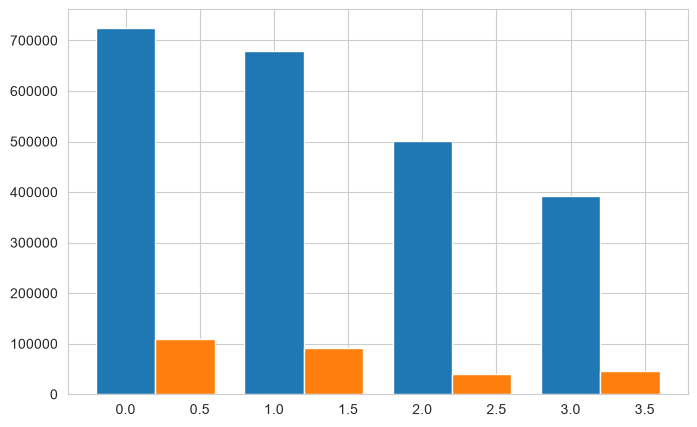

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
Q1_data = pd.read_sql_query(Q1, conn)
x = np.arange(len(Q1_data))
ax.bar(x, Q1_data['Total_Sales'], width=0.4, label='Total Sales', align='center')
ax.bar(x + 0.4, Q1_data['Total_Profit'], width=0.4, label='Total Profit', align='center')
ax.set_xticks(x + 0.4 / 2)
ax.set_xticklabels(Q1_data['Region'], rotation=45)
ax.set_ylabel('Total Sales and Profit')
ax.set_title('Sales and Profit by Region')
ax.legend()
plt.tight_layout()
plt.show()
